In [1]:
# ============================================================
# NAIVE BAYES CLASSIFICATION ON IRIS DATASET
# ============================================================

# ============================================================
# STEP 1 : IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score
)

# ============================================================
# STEP 2 : LOAD DATASET
# ============================================================

# Load iris dataset from seaborn
df = sns.load_dataset('iris')

# ============================================================
# STEP 3 : DATA EXPLORATION
# ============================================================

print("FIRST 5 ROWS")
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nSHAPE OF DATASET")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

print("\nCHECKING NULL VALUES")
print(df.isnull().sum())

FIRST 5 ROWS
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

LAST 5 ROWS
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

SHAPE OF DATASET
(150, 5)

COLUMN NAMES
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

DATA TYPES
sepal_length 

In [2]:
# ============================================================
# STEP 4 : LABEL ENCODING
# ============================================================

# Convert categorical species into numeric values

# setosa -> 0
# versicolor -> 1
# virginica -> 2

df['species'] = df['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

print("\nAFTER ENCODING")
print(df.head())




AFTER ENCODING
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [3]:
# ============================================================
# STEP 5 : FEATURE SELECTION
# ============================================================

# X = input features
# y = target/output column

X = df.drop('species', axis=1)
y = df['species']

print("\nFEATURES SHAPE :", X.shape)
print("TARGET SHAPE :", y.shape)




FEATURES SHAPE : (150, 4)
TARGET SHAPE : (150,)


In [4]:
# ============================================================
# STEP 6 : TRAIN TEST SPLIT
# ============================================================

# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)




X_train shape : (120, 4)
X_test shape : (30, 4)
y_train shape : (120,)
y_test shape : (30,)


In [5]:
# ============================================================
# STEP 7 : TRAIN GAUSSIAN NAIVE BAYES MODEL
# ============================================================

# Create model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [6]:

# ============================================================
# STEP 8 : MODEL PREDICTION
# ============================================================

# Predict output for test data

y_pred = model.predict(X_test)

print("\nPREDICTED VALUES")
print(y_pred)

print("\nACTUAL VALUES")
print(y_test.values)




PREDICTED VALUES
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

ACTUAL VALUES
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [7]:
# ============================================================
# STEP 9 : MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY :", accuracy)




MODEL ACCURACY : 1.0


In [8]:
# ============================================================
# STEP 10 : CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print(cm)




CONFUSION MATRIX
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [9]:
# ============================================================
# STEP 11 : TP, FP, TN, FN
# ============================================================

# Iris is multiclass classification.
# We calculate TP, FP, TN, FN for ONE class.
# Here:
# class 0 (setosa) is treated as positive class.

TP = cm[0][0]

FP = cm[:, 0].sum() - TP

FN = cm[0, :].sum() - TP

TN = cm.sum() - (TP + FP + FN)

print("\nTRUE POSITIVE (TP) :", TP)
print("FALSE POSITIVE (FP) :", FP)
print("FALSE NEGATIVE (FN) :", FN)
print("TRUE NEGATIVE (TN) :", TN)




TRUE POSITIVE (TP) : 10
FALSE POSITIVE (FP) : 0
FALSE NEGATIVE (FN) : 0
TRUE NEGATIVE (TN) : 20


In [10]:
# ============================================================
# STEP 12 : EVALUATION METRICS
# ============================================================

accuracy_metric = (TP + TN) / (TP + TN + FP + FN)

error_rate = 1 - accuracy_metric

precision = TP / (TP + FP)

recall = TP / (TP + FN)

print("\nACCURACY :", accuracy_metric)

print("ERROR RATE :", error_rate)

print("PRECISION :", precision)

print("RECALL :", recall)




ACCURACY : 1.0
ERROR RATE : 0.0
PRECISION : 1.0
RECALL : 1.0


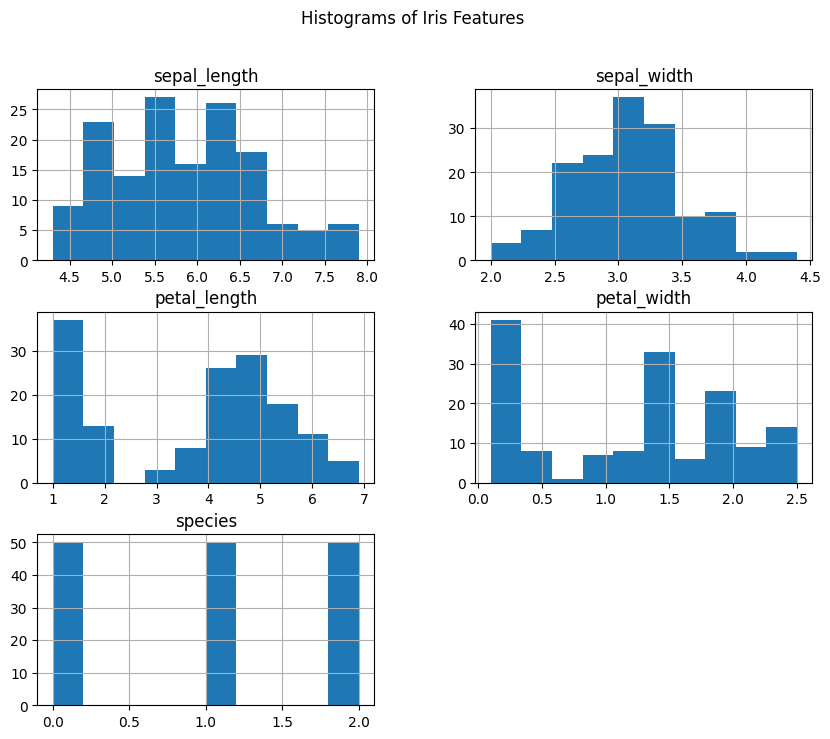

In [11]:
# ============================================================
# STEP 14 : HISTOGRAMS
# ============================================================

# Histograms show feature distributions

df.hist(figsize=(10, 8))

plt.suptitle("Histograms of Iris Features")

plt.show()

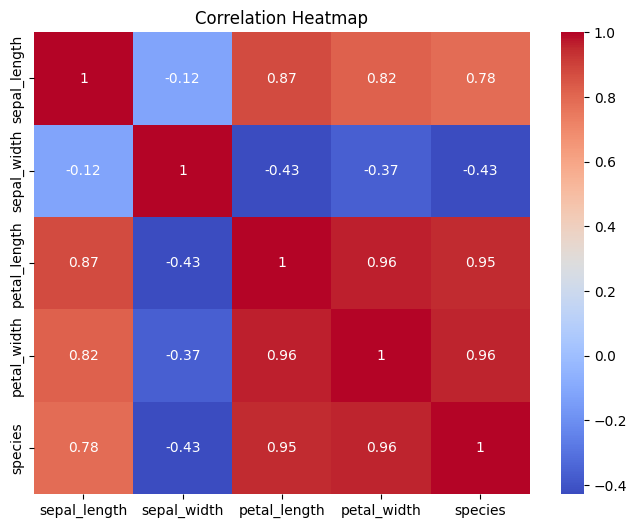

In [12]:
# ============================================================
# STEP 15 : CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()